In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import sklearn.metrics as sm 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster  # Import the fcluster function
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial import distance


In [43]:
# Load your dataframe
all4_gtsB_gtsD_clusters_qua = pd.read_csv('quantitative_variable_contribution_percluster_4-fold_08_consensusf_gtsB_gtsD.csv')
print(all4_gtsB_gtsD_clusters_qua.shape)
print(all4_gtsB_gtsD_clusters_qua.head())
print(all4_gtsB_gtsD_clusters_qua.isnull().sum())
print(all4_gtsB_gtsD_clusters_qua.shape)
print(all4_gtsB_gtsD_clusters_qua.info())

(120, 10)
   gene  cluster                            variables    v.test  \
0  gtsB        1  T-ending codon relative probability -8.426704   
1  gtsB        1  C-ending codon relative probability -7.474167   
2  gtsB        1                  C-ending codon RSCU -6.916618   
3  gtsB        1                  T-ending codon RSCU -5.403268   
4  gtsB        1                          Transitions -4.729488   

   mean_in_cluster  overall_mean  sd_in_cluster  overall_sd       p.value  \
0         0.128804      0.245095       0.088853    0.151803  0.000000e+00   
1         0.282716      0.355577       0.091121    0.107233  7.770000e-14   
2         1.297364      1.801160       0.441990    0.801224  4.630000e-12   
3         0.309818      0.424210       0.085506    0.232879  6.540000e-08   
4       109.481256    169.803745      62.298761  140.300055  2.250000e-06   

   n_in_cluster  
0            55  
1            55  
2            55  
3            55  
4            55  
gene            

In [51]:
##filtering by gene, first gtsB

filtered_gtsBclusters4all_qua = all4_gtsB_gtsD_clusters_qua[all4_gtsB_gtsD_clusters_qua['gene'] == 'gtsB']  
print(filtered_gtsBclusters4all_qua.shape)

(45, 10)


In [52]:
##n sizes per cluster gtsB
n_number= [55,24,21]


In [53]:
# Define a color palette with fixed colors for specific variables
fixed_colors2 = {'A-ending codon relative probability':'dodgerblue','A-ending codon mean W':'#E31A1C','A-ending codon RSCU':'green','C-ending codon relative probability':'#6A3D9A','C-ending codon mean W':'#FF7F00','C-ending codon RSCU':'deeppink','G-ending codon relative probability':'skyblue','G-ending codon mean W':'#FB9A99','G-ending codon RSCU':'khaki','T-ending codon relative probability':'#CAB2D6','T-ending codon mean W':'#FDBF6F','T-ending codon RSCU':'black','Substitution rate':'blue','Transitions':'maroon','Transversions':'orchid'
                }  

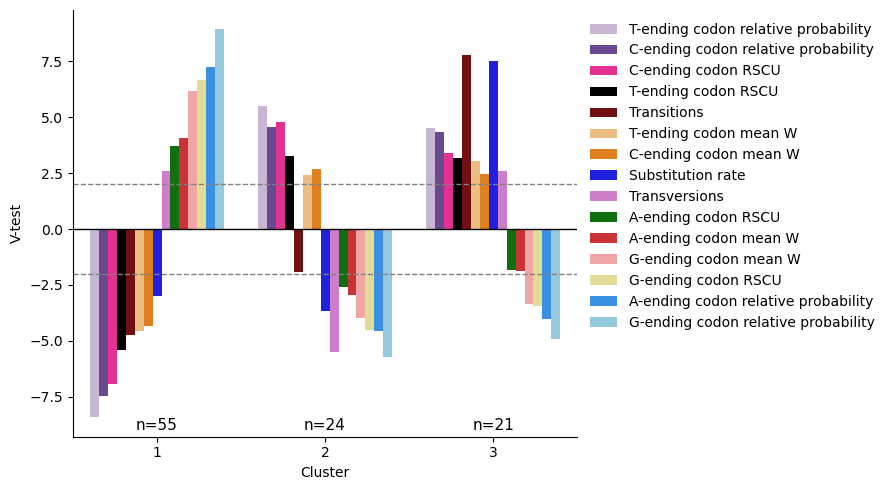

In [54]:

fig = plt.figure(figsize=(9, 5))  

# Create the bar plot
sns.barplot(filtered_gtsBclusters4all_qua, x='cluster', y='v.test', hue='variables', palette=fixed_colors2, linewidth=10)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')

# Add n number (per cluster) under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -9.0, f'n={v}', ha='center', fontsize=11, color='black')

# Set legend position to the right without overlapping
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Variables', ncol=1)


# Add horizontal lines at Y=2 and Y=-2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)
# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

# Remove borders around the graph
sns.despine()

# Remove legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Saving the plot to PNG
plt.savefig('all_quantitative_var_4fold_gtsB_consen_slus_3k_2pca_plot_08.png', dpi=1000)
plt.show()  
    

In [48]:
##filtering by gene, then gtsD

filtered_gtsDclusters4all_qua = all4_gtsB_gtsD_clusters_qua[all4_gtsB_gtsD_clusters_qua['gene'] == 'gtsD']  
print(filtered_gtsDclusters4all_qua.shape)

(75, 10)


In [49]:
##n sizes per cluster gtsD
n_number= [17,33,34,19,29]


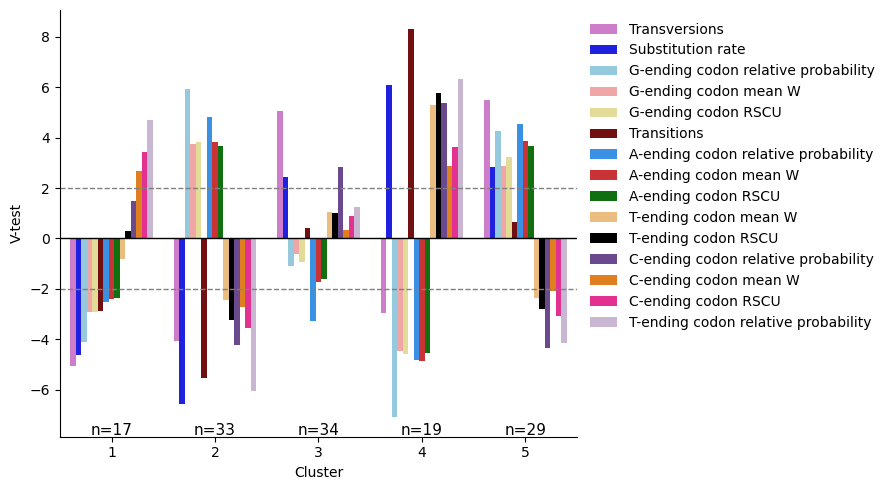

In [50]:
fig = plt.figure(figsize=(9, 5))  
# Create the bar plot
sns.barplot(data=filtered_gtsDclusters4all_qua, x='cluster', y='v.test', hue='variables', palette=fixed_colors2, linewidth=10)

# Add n number (per cluster) under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -7.8, f'n={v}', ha='center', fontsize=11, color='black')
        
        
# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')



# legend position to the right without overlapping
plt.legend(frameon=False,loc='upper left', bbox_to_anchor=(1, 1), title='')

# Adding horizontal lines at Y=2 and Y=-2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)
# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

# Removing borders around the graph
sns.despine()

# Removing legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Saving the plot to PNG
plt.savefig('final_all_quantita_gtsD_4fold_5_consens_clusters_2pcaf_2f_08.png', dpi=1000)
plt.show()  